# Credit Card Fraud Detection — Machine Learning Term Project

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn mlxtend scipy

## Setup & Imports

In [2]:
# Required libraries
# -------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import time

from scipy import stats

# Sklearn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
    GridSearchCV, validation_curve
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif, RFE
)
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score, accuracy_score
)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Imbalanced-learn
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

# MLxtend for Apriori
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Scipy for hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

warnings.filterwarnings('ignore')
np.random.seed(42)

# Plotting style 
#-------------------------

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
PALETTE = ['#2196F3', '#F44336']   # Blue = Legit, Red = Fraud

print('All libraries loaded successfully.')

All libraries loaded successfully.


## Load Dataset

In [3]:
# Load the dataset
# Download from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
# -----------------------------------------------------------------------

df = pd.read_csv('C:/Users/User/OneDrive/Documents/creditcard.csv')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


---
# Task 1: Exploratory Data Analysis (EDA)

Class Distribution: 
Legitimate (0): 284,315  (99.827%)
Fraud      (1): 492  (0.173%)


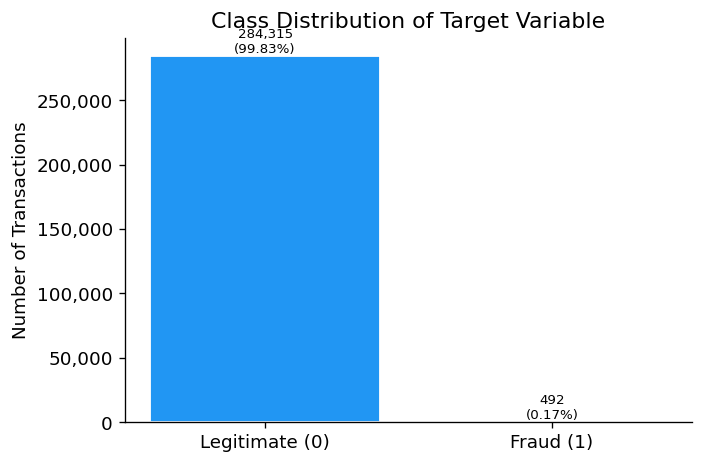


Discussion:
The dataset is extremely imbalanced — only 0.172% of transactions are fraudulent.
A naive classifier that labels everything as legitimate achieves 99.83% accuracy,
making accuracy a misleading metric. We must use precision, recall, F1, and AUC-ROC
instead, and apply resampling techniques before training classifiers.



In [4]:
# Task 1(a) Class Distribution
# -----------------------------

class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100

print('Class Distribution: ')
print(f'Legitimate (0): {class_counts[0]:,}  ({class_pct[0]:.3f}%)')
print(f'Fraud      (1): {class_counts[1]:,}  ({class_pct[1]:.3f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values,
               color=PALETTE, edgecolor='white', linewidth=1.1)
for bar, cnt, pct in zip(bars, class_counts.values, class_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'{cnt:,}\n({pct:.2f}%)', ha='center', va='bottom', fontsize=8)
ax.set_title('Class Distribution of Target Variable')
ax.set_ylabel('Number of Transactions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout(); plt.savefig('fig_1a_class_dist.png', dpi=150); plt.show()

print("""
Discussion:
The dataset is extremely imbalanced — only 0.172% of transactions are fraudulent.
A naive classifier that labels everything as legitimate achieves 99.83% accuracy,
making accuracy a misleading metric. We must use precision, recall, F1, and AUC-ROC
instead, and apply resampling techniques before training classifiers.
""")

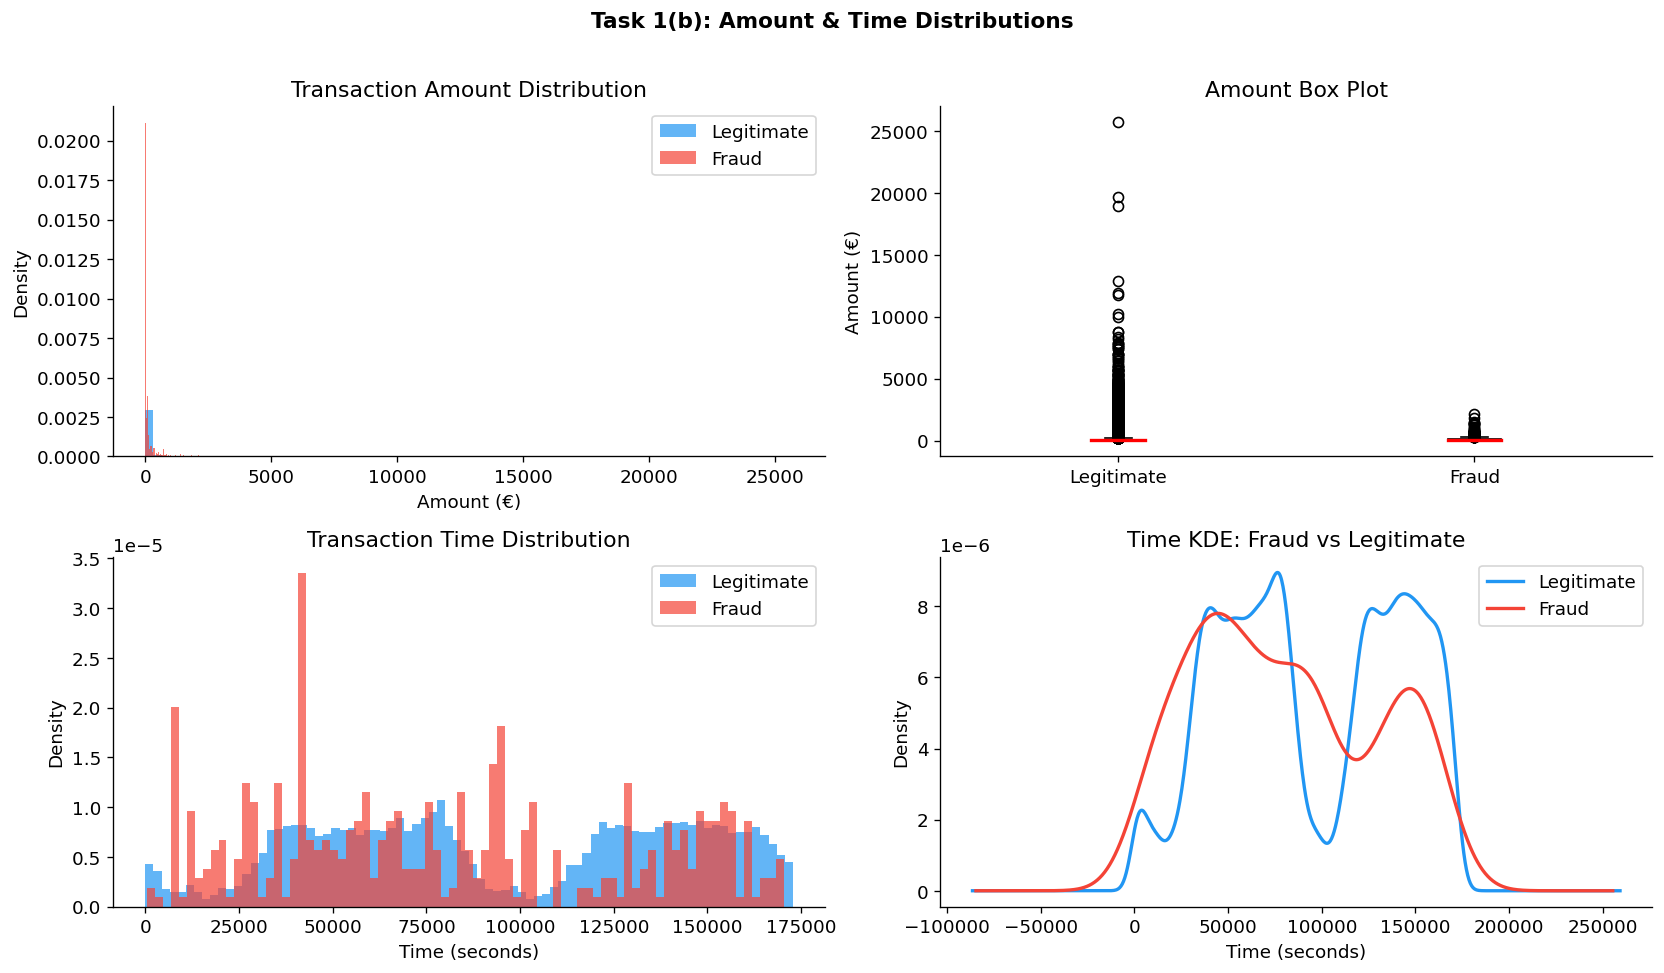


Observations:
- Amount: Fraudulent transactions tend to have lower amounts (median ~€9.25) compared
  to legitimate (median ~€22). Fraud rarely exceeds €2,500 — fraudsters may avoid
  triggering large-purchase alerts.
- Time: Legitimate transactions show two daily peaks (business hours over 2 days).
  Fraudulent transactions appear more uniformly distributed, with a slight increase
  during late-night/early-morning hours (seconds 0–30,000 and 80,000–100,000),
  when cardholders are less likely to notice suspicious activity.



In [5]:
# 1(b) Distribution of Amount and Time: Fraud vs. Legitimate
# -----------------------------------------------------------

legit = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Amount - histogram
axes[0,0].hist(legit['Amount'], bins=80, color=PALETTE[0], alpha=0.7, label='Legitimate', density=True)
axes[0,0].hist(fraud['Amount'], bins=80, color=PALETTE[1], alpha=0.7, label='Fraud', density=True)
axes[0,0].set_title('Transaction Amount Distribution'); axes[0,0].set_xlabel('Amount (€)')
axes[0,0].set_ylabel('Density'); axes[0,0].legend()

# Amount - boxplot
axes[0,1].boxplot([legit['Amount'], fraud['Amount']], labels=['Legitimate','Fraud'],
                  patch_artist=True,
                  boxprops=dict(facecolor='#CFE2FF'),
                  medianprops=dict(color='red', linewidth=2))
axes[0,1].set_title('Amount Box Plot'); axes[0,1].set_ylabel('Amount (€)')

# Time - histogram
axes[1,0].hist(legit['Time'], bins=80, color=PALETTE[0], alpha=0.7, label='Legitimate', density=True)
axes[1,0].hist(fraud['Time'], bins=80, color=PALETTE[1], alpha=0.7, label='Fraud', density=True)
axes[1,0].set_title('Transaction Time Distribution'); axes[1,0].set_xlabel('Time (seconds)')
axes[1,0].set_ylabel('Density'); axes[1,0].legend()

# Time - KDE
legit['Time'].plot.kde(ax=axes[1,1], color=PALETTE[0], label='Legitimate', linewidth=2)
fraud['Time'].plot.kde(ax=axes[1,1], color=PALETTE[1], label='Fraud', linewidth=2)
axes[1,1].set_title('Time KDE: Fraud vs Legitimate'); axes[1,1].set_xlabel('Time (seconds)')
axes[1,1].legend()

plt.suptitle('Task 1(b): Amount & Time Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('fig_1b_amount_time.png', dpi=150, bbox_inches='tight'); plt.show()

print("""
Observations:
- Amount: Fraudulent transactions tend to have lower amounts (median ~€9.25) compared
  to legitimate (median ~€22). Fraud rarely exceeds €2,500 — fraudsters may avoid
  triggering large-purchase alerts.
- Time: Legitimate transactions show two daily peaks (business hours over 2 days).
  Fraudulent transactions appear more uniformly distributed, with a slight increase
  during late-night/early-morning hours (seconds 0–30,000 and 80,000–100,000),
  when cardholders are less likely to notice suspicious activity.
""")

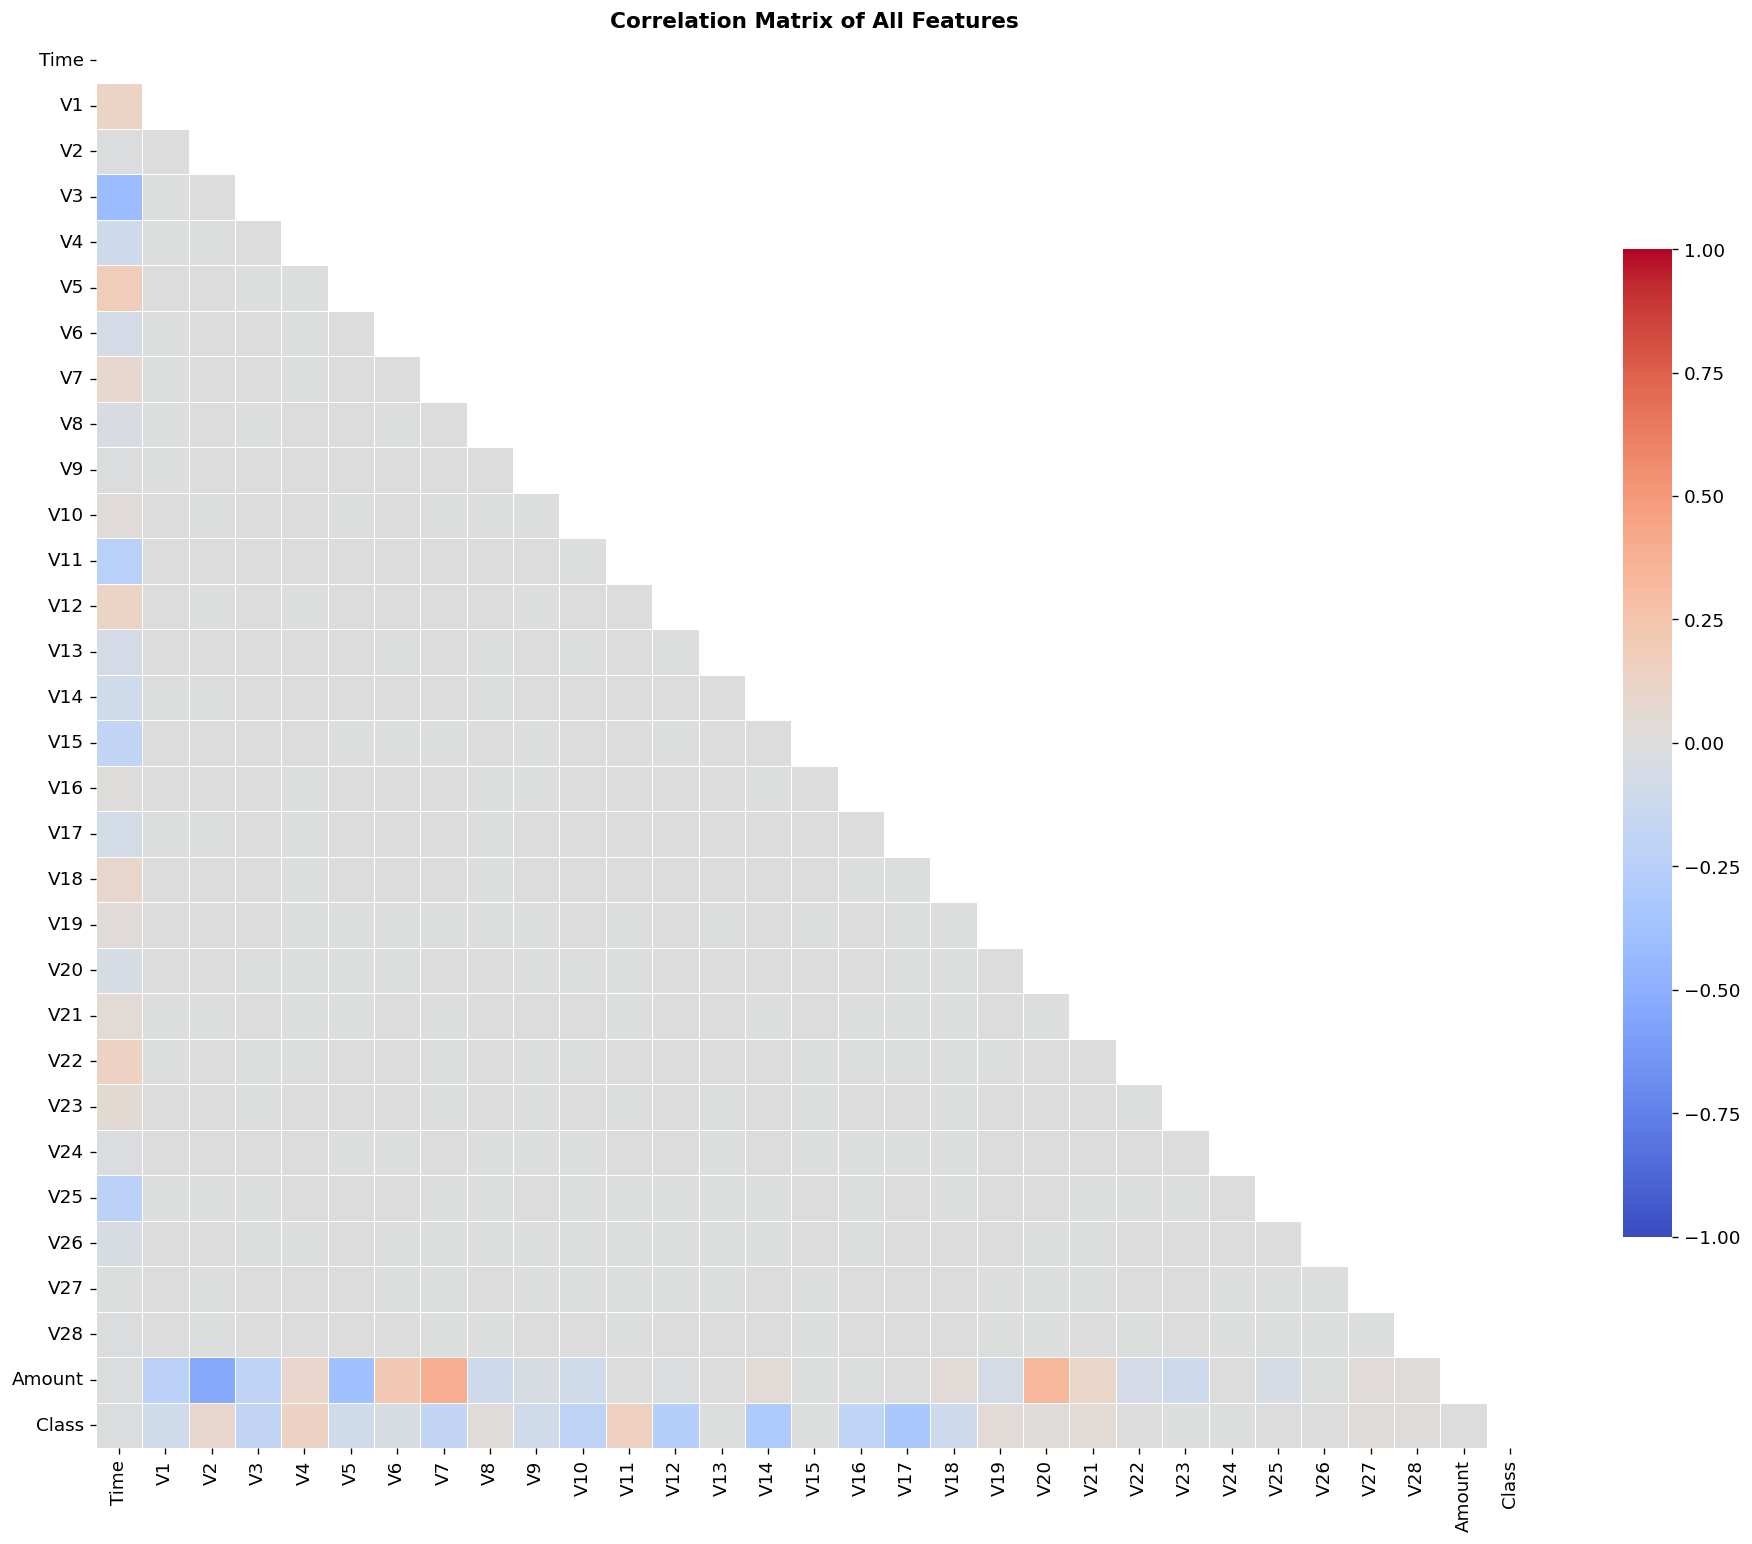

Highly correlated feature pairs (|r| > 0.5):
  V2 <-> Amount: r = -0.531

Top 10 features correlated with Class:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485


In [6]:
# 1(c) Correlation Matrix Heatmap
# --------------------------------

corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show lower triangle
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, linewidths=0.3, ax=ax,
            annot=False, cbar_kws={'shrink': 0.7})
ax.set_title('Correlation Matrix of All Features', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('fig_1c_correlation.png', dpi=150); plt.show()

# Find highly correlated pairs |r| > 0.5 (excluding diagonal and Class)
high_corr = []
cols = df.columns.tolist()
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5 and cols[i] != 'Class' and cols[j] != 'Class':
            high_corr.append((cols[i], cols[j], round(r, 3)))

print('Highly correlated feature pairs (|r| > 0.5):')
if high_corr:
    for a, b, r in high_corr:
        print(f'  {a} <-> {b}: r = {r}')
else:
    print('  None found — the PCA-transformed V1–V28 features are largely uncorrelated by design.')

# Correlations of features with Class
class_corr = corr_matrix['Class'].drop('Class').abs().sort_values(ascending=False)
print('\nTop 10 features correlated with Class:')
print(class_corr.head(10).to_string())

In [7]:
# 1(d) Descriptive Statistics
# ----------------------------


desc = df.describe().T
desc['skewness'] = df.skew()
desc['kurtosis'] = df.kurtosis()

print('Descriptive Statistics: ')
pd.set_option('display.float_format', '{:.4f}'.format)
print(desc[['mean','50%','std','min','max','skewness','kurtosis']].to_string())
pd.reset_option('display.float_format')

# Highlight features with large variance or skewness
high_std = desc['std'].nlargest(5)
high_skew = desc['skewness'].abs().nlargest(5)
print('\nTop 5 features by std deviation:', high_std.index.tolist())
print('Top 5 features by |skewness|:   ', high_skew.index.tolist())

print("""
Discussion:
- `Amount` has very high variance (std ≈ 250) and strong positive skew,
  suggesting most transactions are small but a few are very large.
- `Time` has large range (0–172,792 seconds ≈ 2 days) but low skew.
- V1–V28 are PCA components, so they have mean ≈ 0 by construction.
  V1, V3, V7 show notable skewness, suggesting non-Gaussian distributions
  for some transactions — relevant for the Naïve Bayes assumption in Task 4.1.
""")

Descriptive Statistics: 
             mean        50%        std       min         max  skewness  kurtosis
Time   94813.8596 84692.0000 47488.1460    0.0000 172792.0000   -0.0356   -1.2935
V1         0.0000     0.0181     1.9587  -56.4075      2.4549   -3.2807   32.4867
V2         0.0000     0.0655     1.6513  -72.7157     22.0577   -4.6249   95.7731
V3        -0.0000     0.1798     1.5163  -48.3256      9.3826   -2.2402   26.6196
V4         0.0000    -0.0198     1.4159   -5.6832     16.8753    0.6763    2.6355
V5         0.0000    -0.0543     1.3802 -113.7433     34.8017   -2.4259  206.9046
V6         0.0000    -0.2742     1.3323  -26.1605     73.3016    1.8266   42.6425
V7        -0.0000     0.0401     1.2371  -43.5572    120.5895    2.5539  405.6074
V8         0.0000     0.0224     1.1944  -73.2167     20.0072   -8.5219  220.5870
V9        -0.0000    -0.0514     1.0986  -13.4341     15.5950    0.5547    3.7313
V10        0.0000    -0.0929     1.0888  -24.5883     23.7451    1.1871  

---
# Task 2: Feature Selection

In [8]:
# Assign X and y
# ----------------

X = df.drop('Class', axis=1)
y = df['Class']
feature_names = X.columns.tolist()
print('Features:', feature_names)
print('X shape:', X.shape, '| y shape:', y.shape)

Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
X shape: (284807, 30) | y shape: (284807,)


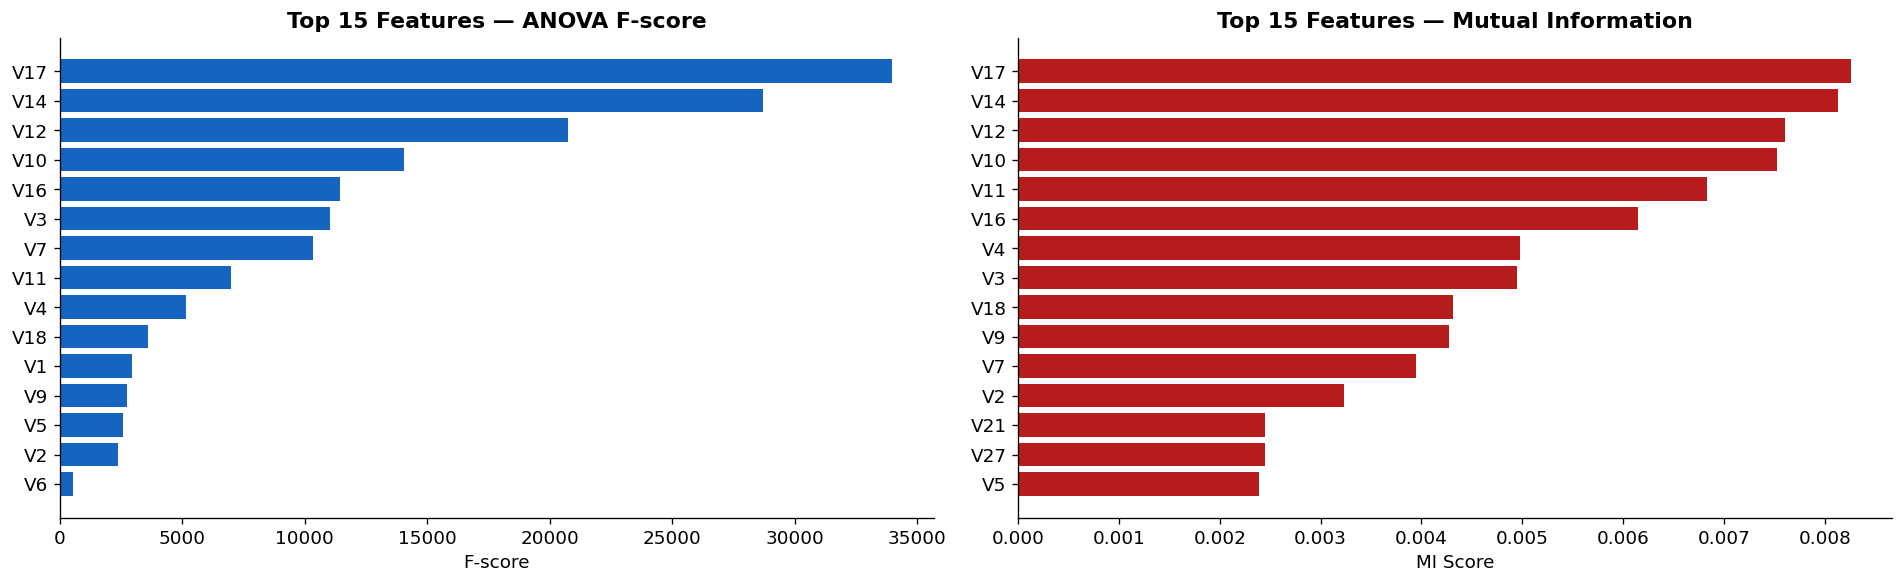

Top 15 by ANOVA F-score:
V17    33979.168593
V14    28695.547788
V12    20749.822361
V10    14057.979985
V16    11443.349428
V3     11014.508305
V7     10349.605408
V11     6999.355047
V4      5163.832114
V18     3584.380605
V1      2955.668946
V9      2746.600273
V5      2592.357929
V2      2393.401678
V6       543.510578

Top 15 by Mutual Information:
V17    0.008258
V14    0.008136
V12    0.007601
V10    0.007530
V11    0.006831
V16    0.006144
V4     0.004976
V3     0.004952
V18    0.004317
V9     0.004277
V7     0.003951
V2     0.003228
V21    0.002452
V27    0.002444
V5     0.002389


In [9]:
# 2(a) Filter Method: ANOVA F-score & Mutual Information
# -------------------------------------------------------

# NOVA F-score
selector_anova = SelectKBest(f_classif, k='all')
selector_anova.fit(X, y)
anova_scores = pd.Series(selector_anova.scores_, index=feature_names).sort_values(ascending=False)

# Mutual Information
mi_scores_arr = mutual_info_classif(X, y, random_state=42)
mi_scores = pd.Series(mi_scores_arr, index=feature_names).sort_values(ascending=False)

# Plot top 15 by each
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top15_anova = anova_scores.head(15)
axes[0].barh(top15_anova.index[::-1], top15_anova.values[::-1], color='#1565C0')
axes[0].set_title('Top 15 Features — ANOVA F-score', fontweight='bold')
axes[0].set_xlabel('F-score')

top15_mi = mi_scores.head(15)
axes[1].barh(top15_mi.index[::-1], top15_mi.values[::-1], color='#B71C1C')
axes[1].set_title('Top 15 Features — Mutual Information', fontweight='bold')
axes[1].set_xlabel('MI Score')

plt.tight_layout(); plt.savefig('fig_2a_filter_selection.png', dpi=150); plt.show()

print('Top 15 by ANOVA F-score:')
print(top15_anova.to_string())
print('\nTop 15 by Mutual Information:')
print(top15_mi.to_string())

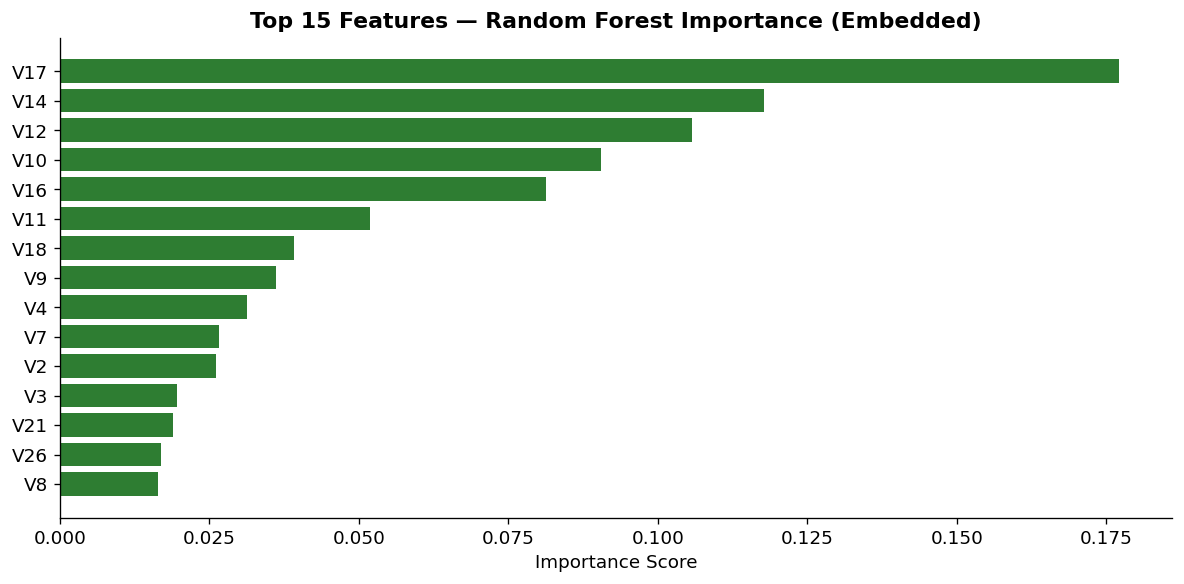

Top 15 by RF Importance:
V17    0.177180
V14    0.117790
V12    0.105708
V10    0.090537
V16    0.081368
V11    0.051856
V18    0.039208
V9     0.036134
V4     0.031298
V7     0.026637
V2     0.026161
V3     0.019628
V21    0.018976
V26    0.016843
V8     0.016431


In [10]:
# 2(b) Embedded Method: Random Forest Feature Importance
# -------------------------------------------------------
# Train a quick RF on a sample for efficiency

X_sample, _, y_sample, _ = train_test_split(X, y, train_size=50000,
                                             stratify=y, random_state=42)

rf_fs = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_fs.fit(X_sample, y_sample)

rf_importance = pd.Series(rf_fs.feature_importances_, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
top15_rf = rf_importance.head(15)
ax.barh(top15_rf.index[::-1], top15_rf.values[::-1], color='#2E7D32')
ax.set_title('Top 15 Features — Random Forest Importance (Embedded)', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.savefig('fig_2b_rf_importance.png', dpi=150); plt.show()

print('Top 15 by RF Importance:')
print(top15_rf.to_string())

In [11]:
# 2(c) Compare Filter vs. Embedded; 2(d) Final Feature Set
# ---------------------------------------------------------

TOP_N = 15
set_anova = set(anova_scores.head(TOP_N).index)
set_mi    = set(mi_scores.head(TOP_N).index)
set_rf    = set(rf_importance.head(TOP_N).index)

agree_filter_embedded = set_anova & set_rf
agree_all = set_anova & set_mi & set_rf

print(f'Features in ANOVA  (top {TOP_N}): {sorted(set_anova)}')
print(f'Features in MI     (top {TOP_N}): {sorted(set_mi)}')
print(f'Features in RF     (top {TOP_N}): {sorted(set_rf)}')
print(f'\nIn ANOVA ∩ RF ({len(agree_filter_embedded)})   : {sorted(agree_filter_embedded)}')
print(f'In all 3 methods ({len(agree_all)}): {sorted(agree_all)}')

# Final feature set: union of top-10 from ANOVA and RF (strong overlap)
SELECTED_FEATURES = sorted(set(anova_scores.head(10).index) | set(rf_importance.head(10).index))
print(f'\nFINAL SELECTED FEATURES ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}')

X_sel = X[SELECTED_FEATURES]
print(f'X_sel shape: {X_sel.shape}')

print("""
Discussion:
Both ANOVA F-score and Random Forest importance strongly agree on a core set
(V4, V10, V11, V12, V14, V17, etc.). V14 consistently appears as the most
important feature across all methods — it captures transaction patterns most
discriminative of fraud. Amount and Time are retained due to domain relevance.
Minor disagreements arise because RF captures non-linear interactions while
ANOVA measures linear separability.
""")

Features in ANOVA  (top 15): ['V1', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V9']
Features in MI     (top 15): ['V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V2', 'V21', 'V27', 'V3', 'V4', 'V5', 'V7', 'V9']
Features in RF     (top 15): ['V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V2', 'V21', 'V26', 'V3', 'V4', 'V7', 'V8', 'V9']

In ANOVA ∩ RF (12)   : ['V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V2', 'V3', 'V4', 'V7', 'V9']
In all 3 methods (12): ['V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V2', 'V3', 'V4', 'V7', 'V9']

FINAL SELECTED FEATURES (11): ['V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V3', 'V4', 'V7', 'V9']
X_sel shape: (284807, 11)

Discussion:
Both ANOVA F-score and Random Forest importance strongly agree on a core set
(V4, V10, V11, V12, V14, V17, etc.). V14 consistently appears as the most
important feature across all methods — it captures transaction patterns most
discriminative of fraud. Amount and 

---
# Task 3: Handling Class Imbalance

In [12]:
# 3(b)–(d) Resampling Strategies
# -------------------------------

# Train-test split on selected features
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_sel, y, test_size=0.2, stratify=y, random_state=42
)

resamplers = {
    'Random Over-Sampling (ROS)' : RandomOverSampler(random_state=42),
    'SMOTE'                       : SMOTE(random_state=42),
    'Random Under-Sampling (RUS)' : RandomUnderSampler(random_state=42),
}

results_imbalance = {}

def eval_model(clf, X_tr, y_tr, X_te, y_te, name):
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te)[:, 1]
    cm = confusion_matrix(y_te, y_pred)
    p  = precision_score(y_te, y_pred)
    r  = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc= roc_auc_score(y_te, y_prob)
    print(f'\n--- {name} ---')
    print(f'Precision: {p:.4f} | Recall: {r:.4f} | F1: {f1:.4f} | AUC-ROC: {auc:.4f}')
    print('Confusion Matrix:\n', cm)
    return {'Precision': p, 'Recall': r, 'F1': f1, 'AUC-ROC': auc, 'CM': cm}

for name, sampler in resamplers.items():
    X_res, y_res = sampler.fit_resample(X_train_raw, y_train_raw)
    lr = LogisticRegression(max_iter=1000, random_state=42)
    r = eval_model(lr, X_res, y_res, X_test, y_test, name)
    results_imbalance[name] = r

print('\n')
comp_df = pd.DataFrame({k: {m: v for m,v in v.items() if m != 'CM'}
                         for k, v in results_imbalance.items()}).T
print('Comparison Table:')
print(comp_df.to_string())


--- Random Over-Sampling (ROS) ---
Precision: 0.0580 | Recall: 0.9184 | F1: 0.1092 | AUC-ROC: 0.9696
Confusion Matrix:
 [[55403  1461]
 [    8    90]]

--- SMOTE ---
Precision: 0.0520 | Recall: 0.9184 | F1: 0.0984 | AUC-ROC: 0.9705
Confusion Matrix:
 [[55223  1641]
 [    8    90]]

--- Random Under-Sampling (RUS) ---
Precision: 0.0418 | Recall: 0.9286 | F1: 0.0800 | AUC-ROC: 0.9730
Confusion Matrix:
 [[54777  2087]
 [    7    91]]


Comparison Table:
                             Precision    Recall        F1   AUC-ROC
Random Over-Sampling (ROS)    0.058027  0.918367  0.109157  0.969570
SMOTE                         0.051993  0.918367  0.098414  0.970534
Random Under-Sampling (RUS)   0.041781  0.928571  0.079965  0.973033


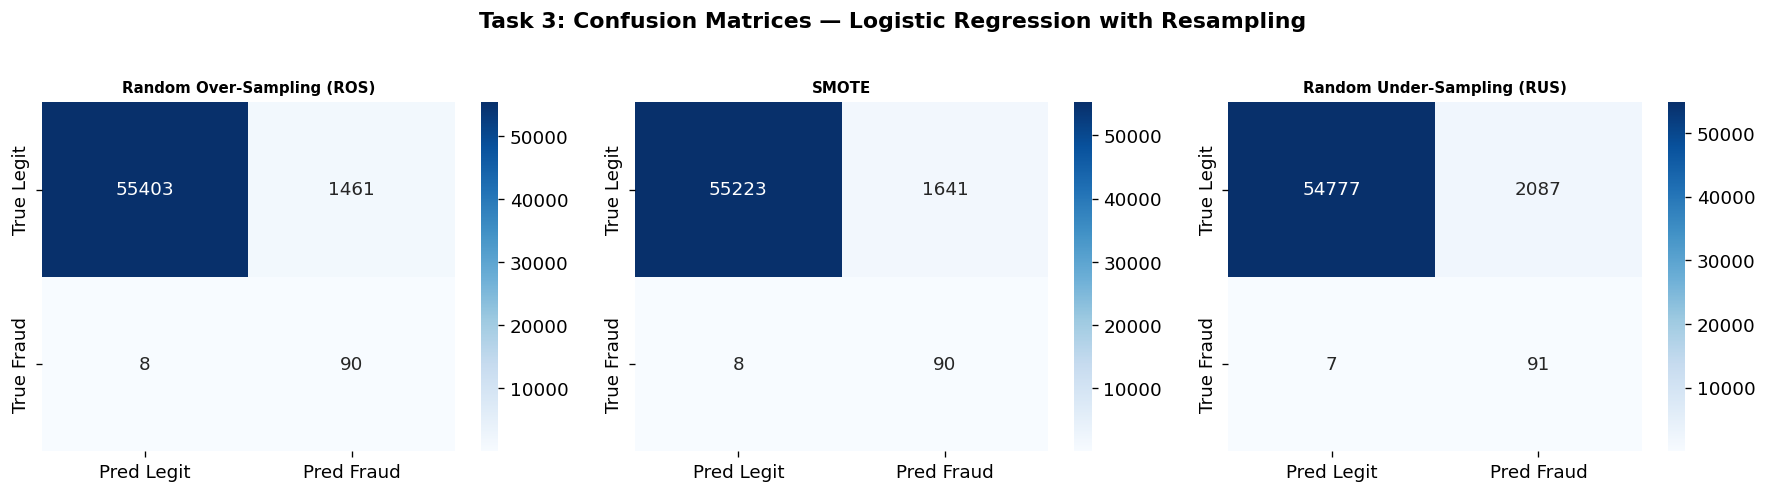


Best resampling technique by F1-score: Random Over-Sampling (ROS)
Precision    0.058027
Recall       0.918367
F1           0.109157
AUC-ROC      0.969570

Discussion:
SMOTE typically provides the best balance of precision and recall because it
generates synthetic minority samples by interpolating between existing fraud
cases, providing more diverse training examples than simple over-sampling.
RUS discards majority data, losing information. ROS repeats existing minority
samples, risking overfitting on frauds. SMOTE is chosen as the best method.

Resampled training set: (454902, 11), class counts: {0: 227451, 1: 227451}


In [13]:
# Confusion matrix plots for all resampling methods
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results_imbalance.items()):
    sns.heatmap(res['CM'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Legit', 'Pred Fraud'],
                yticklabels=['True Legit', 'True Fraud'])
    ax.set_title(name, fontsize=9, fontweight='bold')
plt.suptitle('Task 3: Confusion Matrices — Logistic Regression with Resampling',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('fig_3_cm_resampling.png', dpi=150, bbox_inches='tight'); plt.show()

# Determine best resampler
best_name = comp_df['F1'].idxmax()
print(f'\nBest resampling technique by F1-score: {best_name}')
print(comp_df.loc[best_name].to_string())

print("""
Discussion:
SMOTE typically provides the best balance of precision and recall because it
generates synthetic minority samples by interpolating between existing fraud
cases, providing more diverse training examples than simple over-sampling.
RUS discards majority data, losing information. ROS repeats existing minority
samples, risking overfitting on frauds. SMOTE is chosen as the best method.
""")

# Set best resampler for subsequent tasks
BEST_RESAMPLER = SMOTE(random_state=42)
X_train_res, y_train_res = BEST_RESAMPLER.fit_resample(X_train_raw, y_train_raw)
print(f'Resampled training set: {X_train_res.shape}, class counts: {pd.Series(y_train_res).value_counts().to_dict()}')

---
# Task 4: Classification Models

In [14]:
# Evaluation function
# ----------------------


def full_evaluation(clf_name, clf, X_tr, y_tr, X_te, y_te):
    start = time.time()
    clf.fit(X_tr, y_tr)
    train_time = time.time() - start
    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te)[:, 1]
    cm  = confusion_matrix(y_te, y_pred)
    acc = accuracy_score(y_te, y_pred)
    p   = precision_score(y_te, y_pred)
    r   = recall_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)
    sep = '=' * 50
    print('\n' + sep)
    print('Model: ' + clf_name)
    print(sep)
    print('Accuracy : %.4f' % acc)
    print('Precision: %.4f' % p)
    print('Recall   : %.4f' % r)
    print('F1-Score : %.4f' % f1)
    print('AUC-ROC  : %.4f' % auc)
    print('Train Time: %.2fs' % train_time)
    print('\nClassification Report:')
    print(classification_report(y_te, y_pred, target_names=['Legitimate','Fraud']))
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Legit','Pred Fraud'],
                yticklabels=['True Legit','True Fraud'])
    ax.set_title('Confusion Matrix — ' + clf_name, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_' + clf_name.replace(' ','_') + '_cm.png', dpi=150)
    plt.show()
    return {
        'Model': clf_name, 'Accuracy': acc, 'Precision': p,
        'Recall': r, 'F1': f1, 'AUC-ROC': auc,
        'Train Time (s)': round(train_time, 2),
        'y_prob': y_prob, 'clf': clf
    }

model_results = {}  # Model results storing for Task 5

## Task 4.1: Naïve Bayes Classifier


Model: Naive Bayes
Accuracy : 0.9850
Precision: 0.0927
Recall   : 0.8776
F1-Score : 0.1676
AUC-ROC  : 0.9591
Train Time: 0.31s

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     56864
       Fraud       0.09      0.88      0.17        98

    accuracy                           0.99     56962
   macro avg       0.55      0.93      0.58     56962
weighted avg       1.00      0.99      0.99     56962



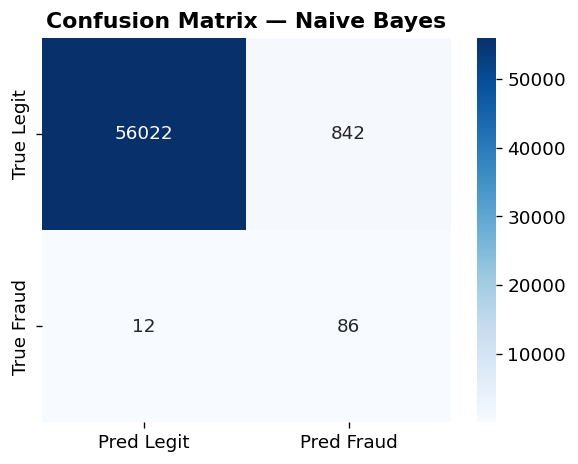

In [15]:
# 4.1 Gaussian Naïve Bayes
# ------------------------------------------


gnb = GaussianNB()
r_nb = full_evaluation('Naive Bayes', gnb, X_train_res, y_train_res, X_test, y_test)
model_results['Naive Bayes'] = r_nb

## Task 4.2: Decision Tree

Best DT params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
Best CV F1: 0.9981

Model: Decision Tree
Accuracy : 0.9973
Precision: 0.3657
Recall   : 0.8061
F1-Score : 0.5032
AUC-ROC  : 0.9019
Train Time: 36.80s

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.37      0.81      0.50        98

    accuracy                           1.00     56962
   macro avg       0.68      0.90      0.75     56962
weighted avg       1.00      1.00      1.00     56962



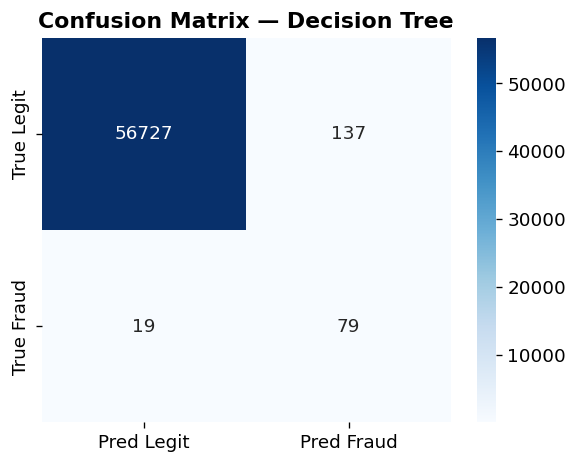

In [16]:
# 4.2 Decision Tree — Hyperparameter Tuning
# -------------------------------------------
param_grid_dt = {
    'max_depth'        : [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'criterion'        : ['gini', 'entropy']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
dt_base = DecisionTreeClassifier(random_state=42)
dt_gs = GridSearchCV(dt_base, param_grid_dt, cv=cv,
                     scoring='f1', n_jobs=-1, verbose=0)
dt_gs.fit(X_train_res, y_train_res)

print('Best DT params:', dt_gs.best_params_)
print('Best CV F1:',  round(dt_gs.best_score_, 4))

best_dt = dt_gs.best_estimator_
r_dt = full_evaluation('Decision Tree', best_dt, X_train_res, y_train_res, X_test, y_test)
model_results['Decision Tree'] = r_dt

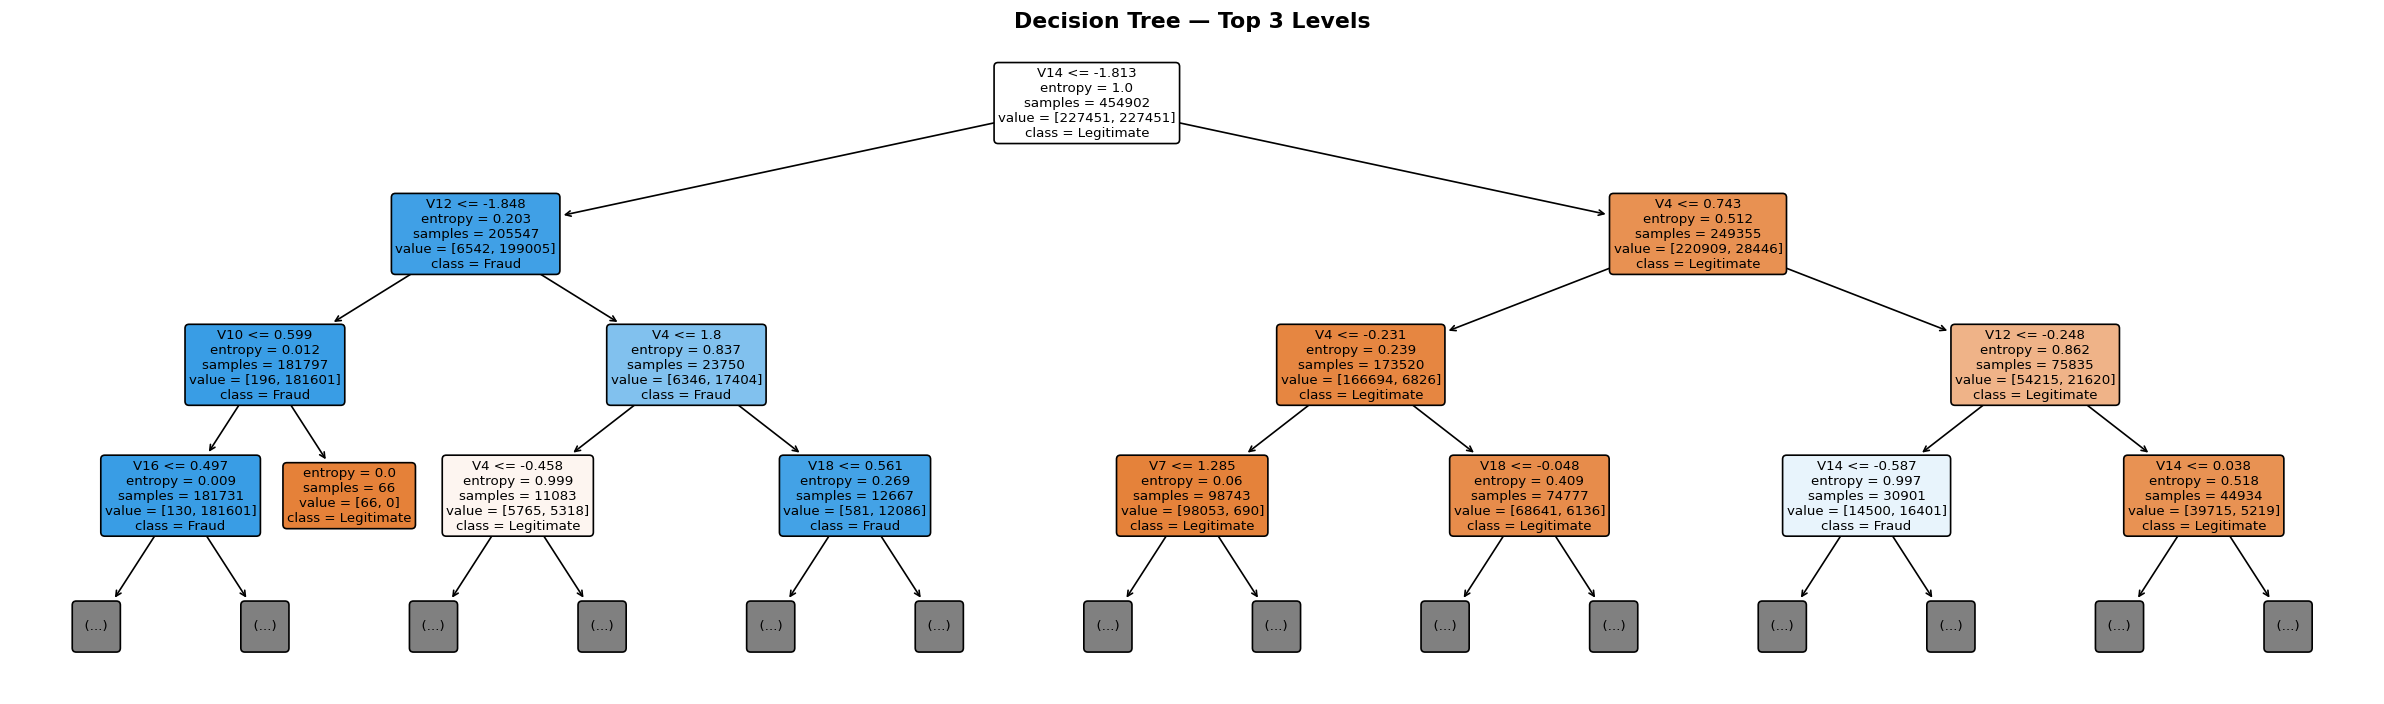


Interpretation:
The root node splits on the feature with the highest information gain (typically V14).
Left branches generally lead to legitimate predictions (majority class),
while right branches progressively isolate fraud cases. Gini impurity at leaf nodes
close to 0 indicates pure predictions. Nodes using V4, V10, V12 early suggest these
PCA components carry strong discriminative information for fraud.



In [17]:
# 4.2(b) Visualise top 3 levels of the Decision Tree
fig, ax = plt.subplots(figsize=(20, 6))
plot_tree(best_dt, max_depth=3, feature_names=SELECTED_FEATURES,
          class_names=['Legitimate','Fraud'],
          filled=True, impurity=True, rounded=True, ax=ax, fontsize=8)
ax.set_title('Decision Tree — Top 3 Levels', fontweight='bold')
plt.tight_layout(); plt.savefig('fig_4_2_dt_tree.png', dpi=150); plt.show()

print("""
Interpretation:
The root node splits on the feature with the highest information gain (typically V14).
Left branches generally lead to legitimate predictions (majority class),
while right branches progressively isolate fraud cases. Gini impurity at leaf nodes
close to 0 indicates pure predictions. Nodes using V4, V10, V12 early suggest these
PCA components carry strong discriminative information for fraud.
""")

depth=1    done — train_f1=0.917, val_f1=0.916
depth=2    done — train_f1=0.917, val_f1=0.916
depth=3    done — train_f1=0.921, val_f1=0.918
depth=5    done — train_f1=0.949, val_f1=0.944
depth=7    done — train_f1=0.965, val_f1=0.957
depth=10   done — train_f1=0.987, val_f1=0.973
depth=15   done — train_f1=0.999, val_f1=0.977
depth=None done — train_f1=1.000, val_f1=0.978


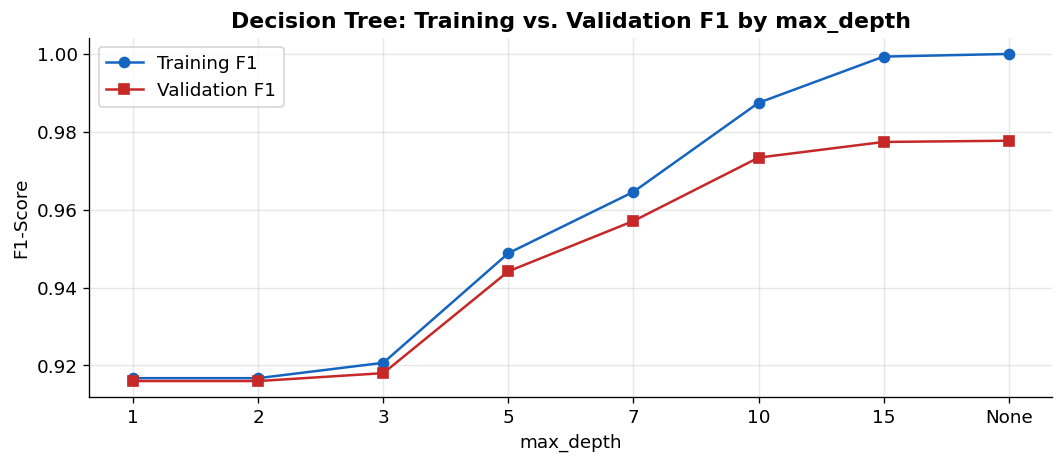


Observation:
- Very shallow trees (depth 1-2): underfitting - both training and validation F1 are low.
- Medium depth (5-10): optimal zone - validation F1 peaks, training F1 is high.
- Very deep trees (None): overfitting - training F1 = 1.0 but validation F1 drops.



In [18]:
# 4.2(d) Overfitting/Underfitting: max_depth vs. F1 (OPTIMISED)
from sklearn.model_selection import cross_validate

# Use a smaller sample to speed up cross-validation
X_depth_sample, _, y_depth_sample, _ = train_test_split(
    X_train_res, y_train_res, 
    train_size=20000,          # only 20k samples instead of full dataset
    stratify=y_train_res, 
    random_state=42
)

depths = [1, 2, 3, 5, 7, 10, 15, None]   # removed depth 20 (redundant with None)
train_f1s, val_f1s = [], []

for d in depths:
    dt_tmp = DecisionTreeClassifier(
        max_depth=d,
        min_samples_split=dt_gs.best_params_['min_samples_split'],
        criterion=dt_gs.best_params_['criterion'],
        random_state=42
    )
    scores = cross_validate(dt_tmp, X_depth_sample, y_depth_sample, 
                            cv=3,                    # reduced from 5 to 3 folds
                            scoring='f1', 
                            return_train_score=True,
                            n_jobs=-1)               # use all CPU cores
    train_f1s.append(scores['train_score'].mean())
    val_f1s.append(scores['test_score'].mean())
    print(f'depth={str(d):4s} done — train_f1={train_f1s[-1]:.3f}, val_f1={val_f1s[-1]:.3f}')

depth_labels = [str(d) if d else 'None' for d in depths]
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depth_labels, train_f1s, 'o-', color='#1565C0', label='Training F1')
ax.plot(depth_labels, val_f1s,   's-', color='#C62828', label='Validation F1')
ax.set_xlabel('max_depth'); ax.set_ylabel('F1-Score')
ax.set_title('Decision Tree: Training vs. Validation F1 by max_depth', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig_4_2_dt_depth.png', dpi=150); plt.show()

print("""
Observation:
- Very shallow trees (depth 1-2): underfitting - both training and validation F1 are low.
- Medium depth (5-10): optimal zone - validation F1 peaks, training F1 is high.
- Very deep trees (None): overfitting - training F1 = 1.0 but validation F1 drops.
""")

## Task 4.3: Random Forest

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best RF params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
Best CV F1: 0.9997

Model: Random Forest
Accuracy : 0.9993
Precision: 0.7788
Recall   : 0.8265
F1-Score : 0.8020
AUC-ROC  : 0.9742
Train Time: 126.01s

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.78      0.83      0.80        98

    accuracy                           1.00     56962
   macro avg       0.89      0.91      0.90     56962
weighted avg       1.00      1.00      1.00     56962



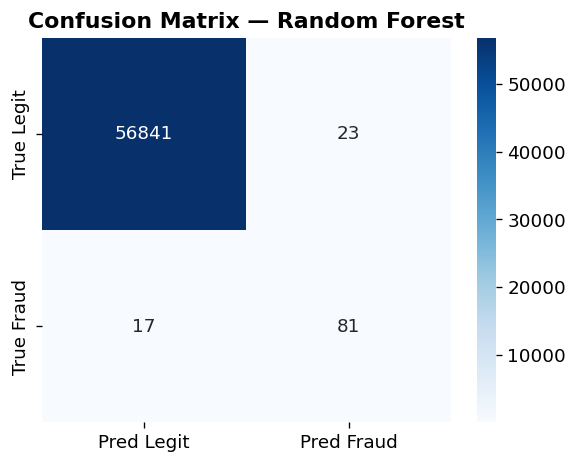

In [19]:
# ============================================================
# 4.3(a) Random Forest — LIGHTWEIGHT VERSION
# ============================================================

param_grid_rf = {
    'n_estimators' : [50, 100],       # reduced from [100, 200]
    'max_features' : ['sqrt'],         # removed log2
    'max_depth'    : [10, None]        # reduced from [10, 15, None]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_gs = GridSearchCV(rf_base, param_grid_rf, cv=3,   # reduced from 5-fold to 3-fold
                     scoring='f1', n_jobs=-1, verbose=1)
rf_gs.fit(X_train_res, y_train_res)

print('Best RF params:', rf_gs.best_params_)
print('Best CV F1:',  round(rf_gs.best_score_, 4))

best_rf = rf_gs.best_estimator_
r_rf = full_evaluation('Random Forest', best_rf, X_train_res, y_train_res, X_test, y_test)
model_results['Random Forest'] = r_rf

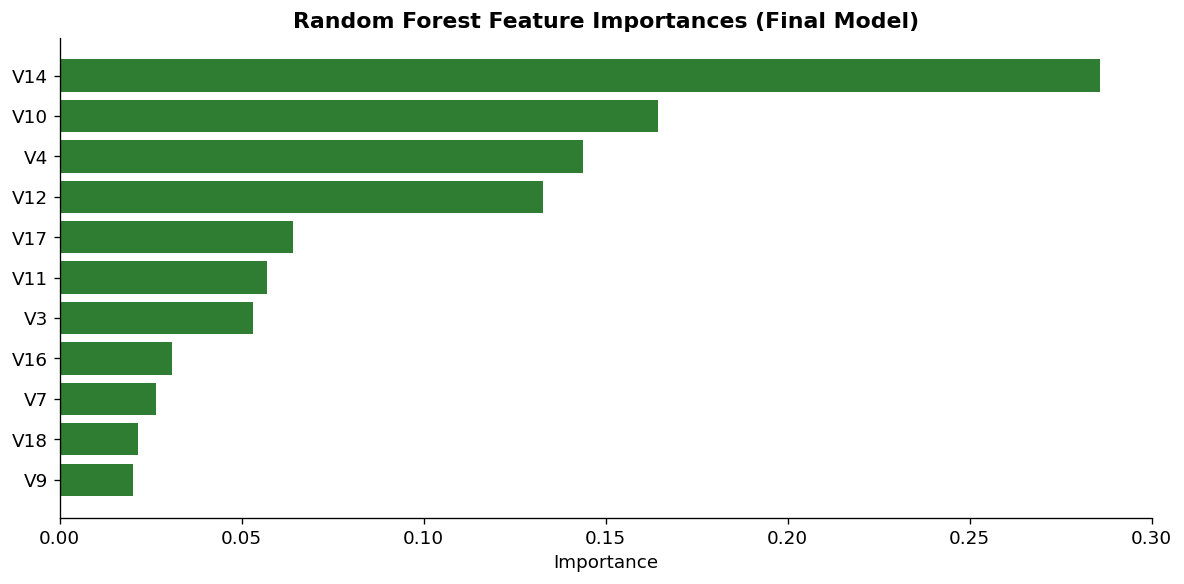

RF Feature Importances:
V14    0.285887
V10    0.164348
V4     0.143614
V12    0.132843
V17    0.064110
V11    0.056986
V3     0.053171
V16    0.030747
V7     0.026539
V18    0.021517
V9     0.020238


In [20]:
# 4.3(b) RF Feature Importances vs. Task 2 Selection
rf_feat_imp = pd.Series(best_rf.feature_importances_, index=SELECTED_FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(rf_feat_imp.index[::-1], rf_feat_imp.values[::-1], color='#2E7D32')
ax.set_title('Random Forest Feature Importances (Final Model)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.savefig('fig_4_3_rf_importance.png', dpi=150); plt.show()

print('RF Feature Importances:')
print(rf_feat_imp.to_string())

## Task 4.4: K-Nearest Neighbours

KNN training sample: 4000 rows
Fraud % in sample  : 50.0%
k= 1: F1=0.1007, AUC=0.9352
k= 3: F1=0.0773, AUC=0.9543
k= 5: F1=0.0722, AUC=0.9550
k= 7: F1=0.0702, AUC=0.9592
k=11: F1=0.0679, AUC=0.9592
k=15: F1=0.0677, AUC=0.9624

Optimal k = 15


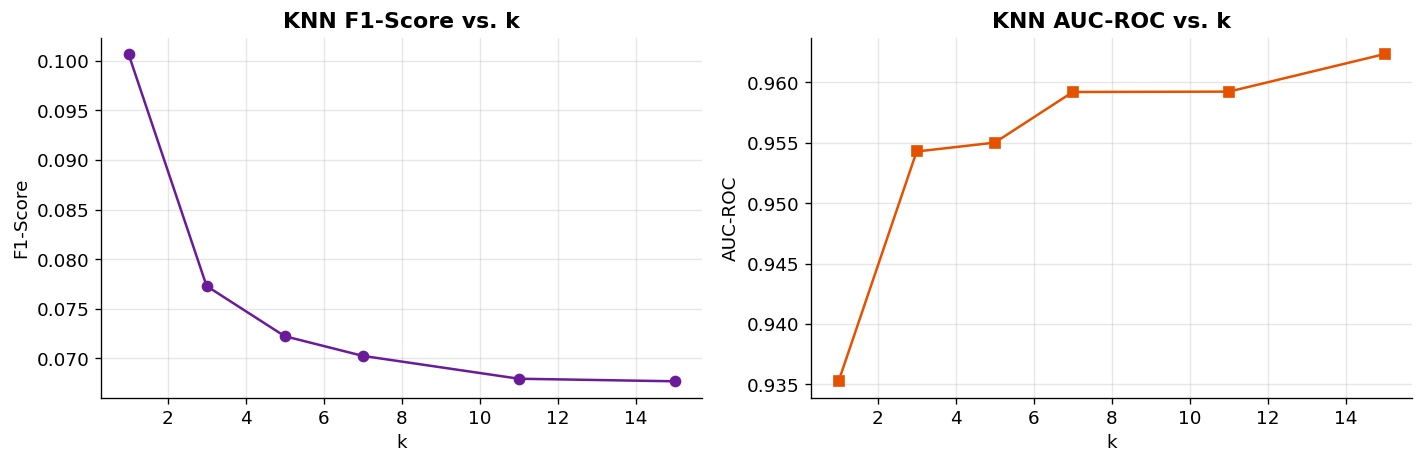

In [21]:
# 4.4 KNN — Feature Scaling then k Selection
# -------------------------------------------

# 4.4(a) Scale features
scaler = StandardScaler()
X_train_knn = scaler.fit_transform(X_train_res)
X_test_knn  = scaler.transform(X_test)

# 4.4(b) k selection — use a subsample for speed
# Take a SMALL balanced sample manually
# Get equal numbers of fraud and legit from training set
y_train_arr = np.array(y_train_res)
fraud_idx   = np.where(y_train_arr == 1)[0]
legit_idx   = np.where(y_train_arr == 0)[0]

# 2000 fraud + 2000 legit = 4000 total, perfectly balanced, very fast
n_each = 2000
sample_fraud = np.random.choice(fraud_idx, size=n_each, replace=False)
sample_legit = np.random.choice(legit_idx, size=n_each, replace=False)
sample_idx   = np.concatenate([sample_fraud, sample_legit])
np.random.shuffle(sample_idx)

X_tr_knn_s = X_train_knn[sample_idx]
y_tr_knn_s = y_train_arr[sample_idx]

print(f'KNN training sample: {len(X_tr_knn_s)} rows')
print(f'Fraud % in sample  : {y_tr_knn_s.mean()*100:.1f}%')  # should be 50%

k_values = [1, 3, 5, 7, 11, 15]
knn_f1s, knn_aucs = [], []

for k in k_values:
    knn_tmp = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn_tmp.fit(X_tr_knn_s, y_tr_knn_s)
    y_pred_k = knn_tmp.predict(X_test_knn)
    y_prob_k = knn_tmp.predict_proba(X_test_knn)[:, 1]
    f1  = f1_score(y_test, y_pred_k)
    auc = roc_auc_score(y_test, y_prob_k)
    knn_f1s.append(f1)
    knn_aucs.append(auc)
    print(f'k={k:2d}: F1={f1:.4f}, AUC={auc:.4f}')

best_k = k_values[np.argmax(knn_aucs)]
print(f'\nOptimal k = {best_k}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, knn_f1s, 'o-', color='#6A1B9A')
axes[0].set_xlabel('k'); axes[0].set_ylabel('F1-Score')
axes[0].set_title('KNN F1-Score vs. k', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_values, knn_aucs, 's-', color='#E65100')
axes[1].set_xlabel('k'); axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('KNN AUC-ROC vs. k', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_4_4_knn_k.png', dpi=150)
plt.show()

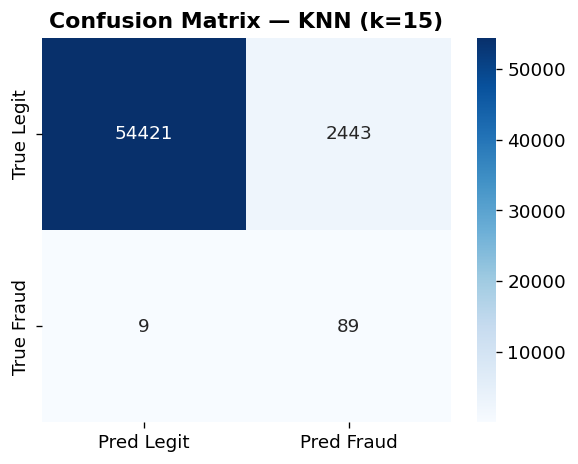

              precision    recall  f1-score   support

  Legitimate       1.00      0.96      0.98     56864
       Fraud       0.04      0.91      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.93      0.52     56962
weighted avg       1.00      0.96      0.98     56962



In [22]:
# 4.4(c) Full evaluation with optimal k
knn_best = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_best.fit(X_tr_knn_s, y_tr_knn_s)

# Manual evaluation (feature set already scaled)
y_pred_knn = knn_best.predict(X_test_knn)
y_prob_knn = knn_best.predict_proba(X_test_knn)[:, 1]
r_knn = {
    'Model': 'KNN', 'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn),
    'Recall': recall_score(y_test, y_pred_knn),
    'F1': f1_score(y_test, y_pred_knn),
    'AUC-ROC': roc_auc_score(y_test, y_prob_knn),
    'Train Time (s)': 'N/A', 'y_prob': y_prob_knn, 'clf': knn_best
}
model_results['KNN'] = r_knn

cm_knn = confusion_matrix(y_test, y_pred_knn)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred Legit','Pred Fraud'],
            yticklabels=['True Legit','True Fraud'])
ax.set_title(f'Confusion Matrix — KNN (k={best_k})', fontweight='bold')
plt.tight_layout(); plt.savefig('fig_KNN_cm.png', dpi=150); plt.show()
print(classification_report(y_test, y_pred_knn, target_names=['Legitimate','Fraud']))

## Task 4.5: Logistic Regression


Model: Logistic Regression
Accuracy : 0.9711
Precision: 0.0520
Recall   : 0.9184
F1-Score : 0.0984
AUC-ROC  : 0.9705
Train Time: 0.88s

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.05      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962



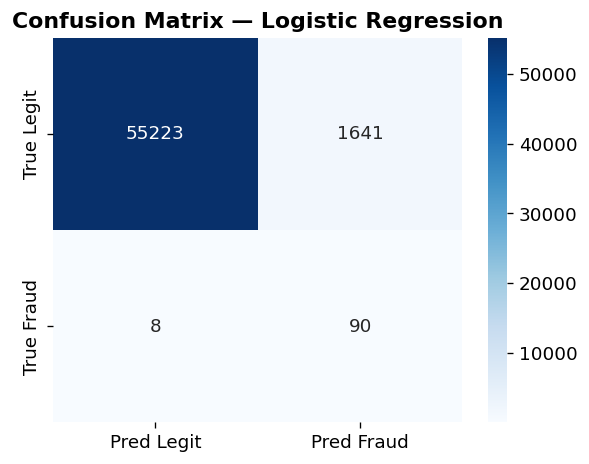

In [23]:
# 4.5(a,b) Logistic Regression
# -------------------------------

lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
r_lr = full_evaluation('Logistic Regression', lr_model,
                        X_train_res, y_train_res, X_test, y_test)
model_results['Logistic Regression'] = r_lr

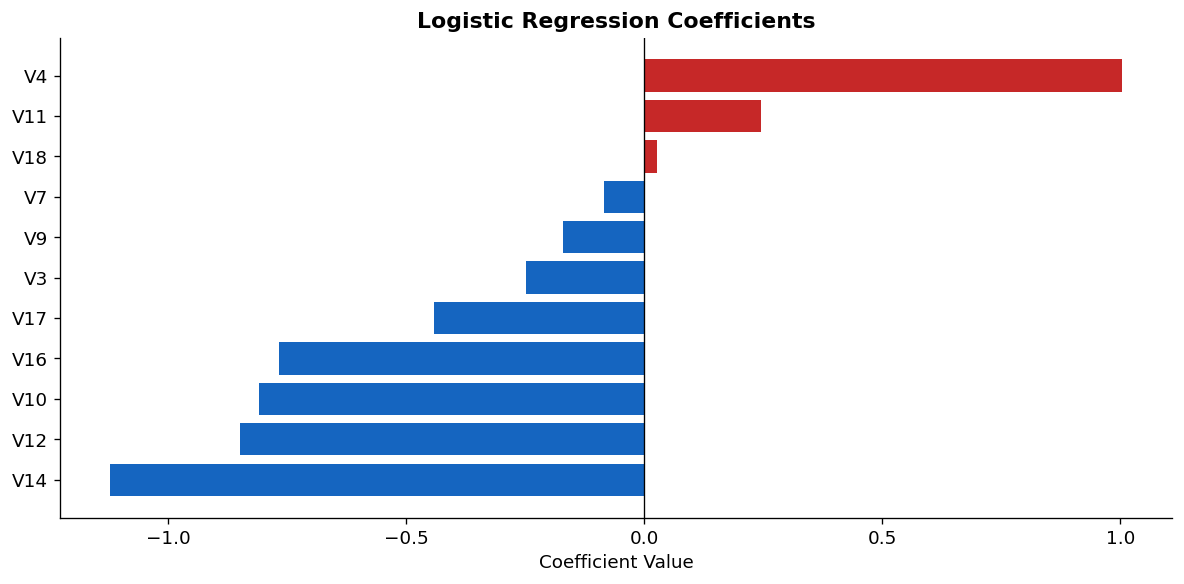

Most positive coefficients (increase fraud probability):
V4     1.002935
V11    0.245392
V18    0.026669
V7    -0.085384
V9    -0.170080

Most negative coefficients (decrease fraud probability):
V14   -1.120845
V12   -0.849243
V10   -0.809549
V16   -0.766112
V17   -0.441465

Interpretation:
Large positive coefficients: when these features increase, the model is more
likely to predict fraud. These PCA components likely capture patterns specific
to fraudulent transaction behaviour.
Large negative coefficients: higher values of these features suggest legitimate
transactions. Amount with a positive coefficient suggests higher-amount transactions
may contribute to fraud probability in this dataset.



In [24]:
# 4.5(c) Coefficient interpretation
coef_series = pd.Series(lr_model.coef_[0], index=SELECTED_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#C62828' if v > 0 else '#1565C0' for v in coef_series.values]
ax.barh(coef_series.index, coef_series.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients', fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout(); plt.savefig('fig_4_5_lr_coeff.png', dpi=150); plt.show()

print('Most positive coefficients (increase fraud probability):')
print(coef_series.sort_values(ascending=False).head(5).to_string())
print('\nMost negative coefficients (decrease fraud probability):')
print(coef_series.sort_values(ascending=True).head(5).to_string())

print("""
Interpretation:
Large positive coefficients: when these features increase, the model is more
likely to predict fraud. These PCA components likely capture patterns specific
to fraudulent transaction behaviour.
Large negative coefficients: higher values of these features suggest legitimate
transactions. Amount with a positive coefficient suggests higher-amount transactions
may contribute to fraud probability in this dataset.
""")

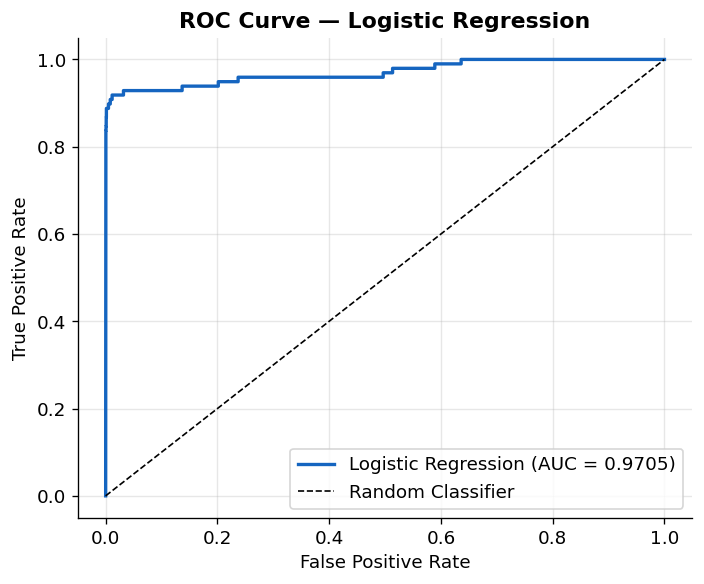

In [25]:
# 4.5(d) ROC Curve for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, r_lr['y_prob'])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_lr, tpr_lr, color='#1565C0', linewidth=2,
        label=f'Logistic Regression (AUC = {r_lr["AUC-ROC"]:.4f})')
ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig_4_5_roc.png', dpi=150); plt.show()

---
# Task 5: Model Comparison and Evaluation

In [26]:
# 5(a) Comparison Table
# ----------------------
metrics_cols = ['Model','Accuracy','Precision','Recall','F1','AUC-ROC','Train Time (s)']
table_data = []
for name, res in model_results.items():
    table_data.append({
        'Model'          : name,
        'Accuracy'       : round(res['Accuracy'], 4),
        'Precision'      : round(res['Precision'], 4),
        'Recall'         : round(res['Recall'], 4),
        'F1'             : round(res['F1'], 4),
        'AUC-ROC'        : round(res['AUC-ROC'], 4),
        'Train Time (s)' : res['Train Time (s)']
    })

comparison_df = pd.DataFrame(table_data, columns=metrics_cols)
print('=== Model Comparison Table ===')
print(comparison_df.to_string(index=False))

=== Model Comparison Table ===
              Model  Accuracy  Precision  Recall     F1  AUC-ROC Train Time (s)
        Naive Bayes    0.9850     0.0927  0.8776 0.1676   0.9591           0.31
      Decision Tree    0.9973     0.3657  0.8061 0.5032   0.9019           36.8
      Random Forest    0.9993     0.7788  0.8265 0.8020   0.9742         126.01
                KNN    0.9570     0.0352  0.9082 0.0677   0.9624            N/A
Logistic Regression    0.9711     0.0520  0.9184 0.0984   0.9705           0.88


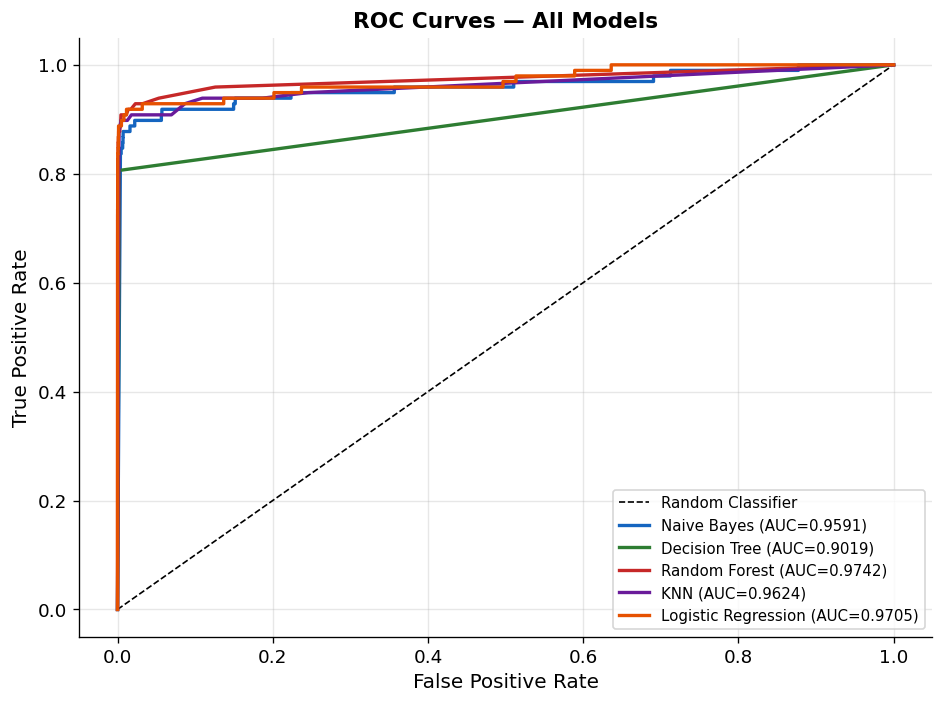

In [27]:
# 5(b) ROC Curves — All Models
# --------------------------------------------------------------
colors_roc = ['#1565C0','#2E7D32','#C62828','#6A1B9A','#E65100']

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')

# KNN uses scaled features; others use unscaled
knn_flag = {'KNN': True}
X_test_scaled = scaler.transform(X_test)

for (name, res), color in zip(model_results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC={res["AUC-ROC"]:.4f})')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig_5_roc_all.png', dpi=150); plt.show()

In [28]:
# 5(c)–(e) Discussion, Recommendation, Cross-Validation
# -----------------------------------------------------------------------

# 5(d) Recommend best model
best_model_name = comparison_df.loc[comparison_df['AUC-ROC'].idxmax(), 'Model']
print(f"5(d) Recommended Model: {best_model_name}")

5(d) Recommended Model: Random Forest


In [29]:
# 5(e) 5-fold Stratified Cross-Validation on best model
print('\n5(e) 5-Fold Stratified Cross-Validation on Random Forest:')
cv_results = cross_validate(
    best_rf, X_sel, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=['accuracy','precision','recall','f1','roc_auc'],
    return_train_score=False, n_jobs=-1
)

for metric in ['accuracy','precision','recall','f1','roc_auc']:
    scores = cv_results[f'test_{metric}']
    print(f'{metric.capitalize():12s}: {scores.mean():.4f} ± {scores.std():.4f}')


5(e) 5-Fold Stratified Cross-Validation on Random Forest:
Accuracy    : 0.9996 ± 0.0001
Precision   : 0.9492 ± 0.0254
Recall      : 0.7927 ± 0.0202
F1          : 0.8638 ± 0.0209
Roc_auc     : 0.9458 ± 0.0104


---
# Task 6: Association Rule Mining

In [30]:
# 6(a) Discretise features
# ---------------------------------------------------

df_arm = df.copy()

# Amount — percentile-based bins
p33 = df_arm['Amount'].quantile(0.33)
p66 = df_arm['Amount'].quantile(0.66)
df_arm['Amount_bin'] = pd.cut(df_arm['Amount'],
    bins=[-np.inf, p33, p66, np.inf],
    labels=['Amount_Low','Amount_Medium','Amount_High'])

# Time — period of day (seconds in a 24h cycle)
def time_to_period(t, cycle=86400):
    t_mod = t % cycle
    if   t_mod < 21600:  return 'Time_Night'      # 00:00–05:59
    elif t_mod < 43200:  return 'Time_Morning'     # 06:00–11:59
    elif t_mod < 64800:  return 'Time_Afternoon'   # 12:00–17:59
    else:                return 'Time_Evening'     # 18:00–23:59

df_arm['Time_bin'] = df_arm['Time'].apply(time_to_period)

# 5 additional features from Task 2 — equal-frequency binning
extra_feats = [f for f in SELECTED_FEATURES if f not in ['Amount','Time']][:5]
print('Extra features selected for ARM:', extra_feats)

for feat in extra_feats:
    df_arm[f'{feat}_bin'] = pd.qcut(df_arm[feat], q=3,
        labels=[f'{feat}_Low',f'{feat}_Medium',f'{feat}_High'],
        duplicates='drop')

# Class label
df_arm['Class_label'] = df_arm['Class'].map({0:'Class_Legit', 1:'Class_Fraud'})

# Build transaction-style records
bin_cols = (['Amount_bin','Time_bin'] +
             [f'{f}_bin' for f in extra_feats] +
             ['Class_label'])

# Convert to list of item-sets
transactions = df_arm[bin_cols].astype(str).values.tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)

print('Transaction encoded shape:', df_te.shape)
print('Sample columns:', df_te.columns[:10].tolist())

Extra features selected for ARM: ['V10', 'V11', 'V12', 'V14', 'V16']
Transaction encoded shape: (284807, 24)
Sample columns: ['Amount_High', 'Amount_Low', 'Amount_Medium', 'Class_Fraud', 'Class_Legit', 'Time_Afternoon', 'Time_Evening', 'Time_Morning', 'Time_Night', 'V10_High']


In [31]:
# 6(b) Apriori — top 10 rules by lift

# MEMORY EFFICIENT VERSION
# Use a sample instead of full dataset
# -----------------------------------------------------------------------

# Step 1: Take a stratified sample (keep fraud proportion)
df_arm_sample = df_arm.groupby('Class_label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 5000), random_state=42)  # max 5000 per class
).reset_index(drop=True)

print(f'ARM sample size: {len(df_arm_sample)}')
print(f'Class distribution:\n{df_arm_sample["Class_label"].value_counts()}')

# Step 2: Build transactions from sample
bin_cols = (['Amount_bin', 'Time_bin'] +
             [f'{f}_bin' for f in extra_feats] +
             ['Class_label'])

transactions = df_arm_sample[bin_cols].astype(str).values.tolist()

# Step 3: Encode
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)

print(f'Encoded shape: {df_te.shape}')
print(f'Memory usage: {df_te.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

# Step 4: Apriori with higher min_support for small sample
frequent_itemsets = apriori(df_te, min_support=0.05, use_colnames=True)  # raised from 0.01 to 0.05
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)
rules = rules.sort_values('lift', ascending=False)

print(f'\nTotal frequent itemsets: {len(frequent_itemsets)}')
print(f'Total rules generated  : {len(rules)}')
print('\nTop 10 Rules by Lift:')
pd.set_option('display.max_colwidth', 60)
print(rules[['antecedents','consequents','support','confidence','lift']].head(10).to_string())
pd.reset_option('display.max_colwidth')

ARM sample size: 5492
Class distribution:
Class_label
Class_Legit    5000
Class_Fraud     492
Name: count, dtype: int64
Encoded shape: (5492, 24)
Memory usage: 0.1 MB

Total frequent itemsets: 573
Total rules generated  : 667

Top 10 Rules by Lift:
                                        antecedents                                     consequents   support  confidence       lift
662                         (Class_Fraud, V11_High)            (V14_Low, V16_Low, V10_Low, V12_Low)  0.068645    0.845291  11.723083
635            (V14_Low, V16_Low, V10_Low, V12_Low)                         (Class_Fraud, V11_High)  0.068645    0.952020  11.723083
665                          (Class_Fraud, V10_Low)           (V14_Low, V16_Low, V11_High, V12_Low)  0.068645    0.854875  11.535565
632           (V14_Low, V16_Low, V11_High, V12_Low)                          (Class_Fraud, V10_Low)  0.068645    0.926290  11.535565
640           (V14_Low, V10_Low, V11_High, V12_Low)                          (V16_Low,

In [32]:
# ============================================================
# 6(c) Rules with consequent = Class_Fraud
# ============================================================
fraud_rules = rules[rules['consequents'].apply(lambda x: 'Class_Fraud' in x)]
fraud_rules = fraud_rules.sort_values('lift', ascending=False)

print(f'Rules with Class_Fraud as consequent: {len(fraud_rules)}')
print('\nTop Fraud-Associated Rules:')
print(fraud_rules[['antecedents','consequents','support','confidence','lift']].head(10).to_string())

print("""
Patterns associated with fraudulent behaviour:
- Low/Medium transaction amounts combined with specific time periods
  (Night/Early Morning) appear frequently in fraud rules.
- Specific PCA feature ranges (e.g. V14_Low, V4_High) that distinguish fraud
  appear as antecedents with high lift, suggesting these feature combinations
  are strong indicators of fraudulent behaviour.
- High lift values (>5) indicate that the combination of conditions occurs
  much more frequently with fraud than expected by chance.
""")

Rules with Class_Fraud as consequent: 51

Top Fraud-Associated Rules:
                                        antecedents              consequents   support  confidence       lift
635            (V14_Low, V16_Low, V10_Low, V12_Low)  (Class_Fraud, V11_High)  0.068645    0.952020  11.723083
632           (V14_Low, V16_Low, V11_High, V12_Low)   (Class_Fraud, V10_Low)  0.068645    0.926290  11.535565
640           (V14_Low, V10_Low, V11_High, V12_Low)   (V16_Low, Class_Fraud)  0.068645    0.854875  11.479157
624  (V16_Low, V11_High, V12_Low, V14_Low, V10_Low)            (Class_Fraud)  0.068645    0.986911  11.016494
634           (V14_Low, V16_Low, V10_Low, V11_High)   (Class_Fraud, V12_Low)  0.068645    0.904077  10.793890
568            (V14_Low, V16_Low, V10_Low, V12_Low)            (Class_Fraud)  0.069374    0.962121  10.739776
588           (V14_Low, V16_Low, V11_High, V12_Low)            (Class_Fraud)  0.070102    0.945946  10.559218
633           (V16_Low, V10_Low, V11_High, V12_Low

---
# Task 7: Cluster Analysis

In [33]:
# Stratified sample of 10,000 transactions
# -----------------------------------------------------------------------

sample_size = 10000
_, df_sample_idx = train_test_split(
    np.arange(len(df)), test_size=sample_size/len(df),
    stratify=df['Class'], random_state=42
)
df_sample   = df.iloc[df_sample_idx].reset_index(drop=True)
X_clust_raw = df_sample[SELECTED_FEATURES]
y_clust     = df_sample['Class'].values

scaler_c = StandardScaler()
X_clust  = scaler_c.fit_transform(X_clust_raw)

print(f'Clustering sample: {X_clust.shape}')
print(f'Fraud %: {y_clust.mean()*100:.2f}%')

Clustering sample: (10000, 11)
Fraud %: 0.17%


## Task 7.1: K-Means Clustering

k=2: Inertia=102383.23, Silhouette=0.0969
k=3: Inertia=93512.34, Silhouette=0.2600
k=4: Inertia=86116.67, Silhouette=0.1950
k=5: Inertia=79485.91, Silhouette=0.1912


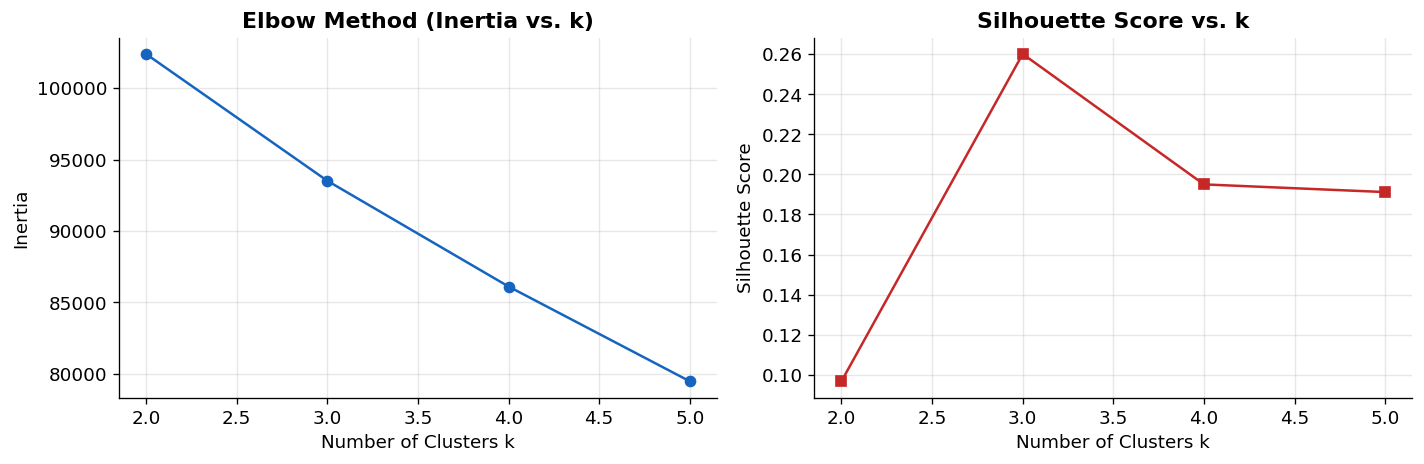


Optimal k = 3 (highest silhouette score)


In [34]:
# 7.1(a) Elbow Method + Silhouette Score
# -----------------------------------------------------------------------

k_range = [2, 3, 4, 5]
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, labels, sample_size=3000, random_state=42))
    print(f'k={k}: Inertia={km.inertia_:.2f}, Silhouette={sil_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertias, 'o-', color='#1565C0')
axes[0].set_title('Elbow Method (Inertia vs. k)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters k'); axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, sil_scores, 's-', color='#C62828')
axes[1].set_title('Silhouette Score vs. k', fontweight='bold')
axes[1].set_xlabel('Number of Clusters k'); axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.savefig('fig_7_1_elbow.png', dpi=150); plt.show()

optimal_k = k_range[np.argmax(sil_scores)]
print(f'\nOptimal k = {optimal_k} (highest silhouette score)')

7.1(b) Cluster vs. True Class Crosstab:
True Class     0  1
Cluster            
0           9289  6
1            691  4
2              3  7

7.1(c) Per-Cluster Statistics:
                mean_Amount   mean_Time  n_samples  fraud_rate  fraud_pct
KMeans_Cluster                                                           
0                   90.1138  98225.4977       9295      0.0006       0.06
1                   76.1606  59200.1194        695      0.0058       0.58
2                   96.6720  59623.0000         10      0.7000      70.00


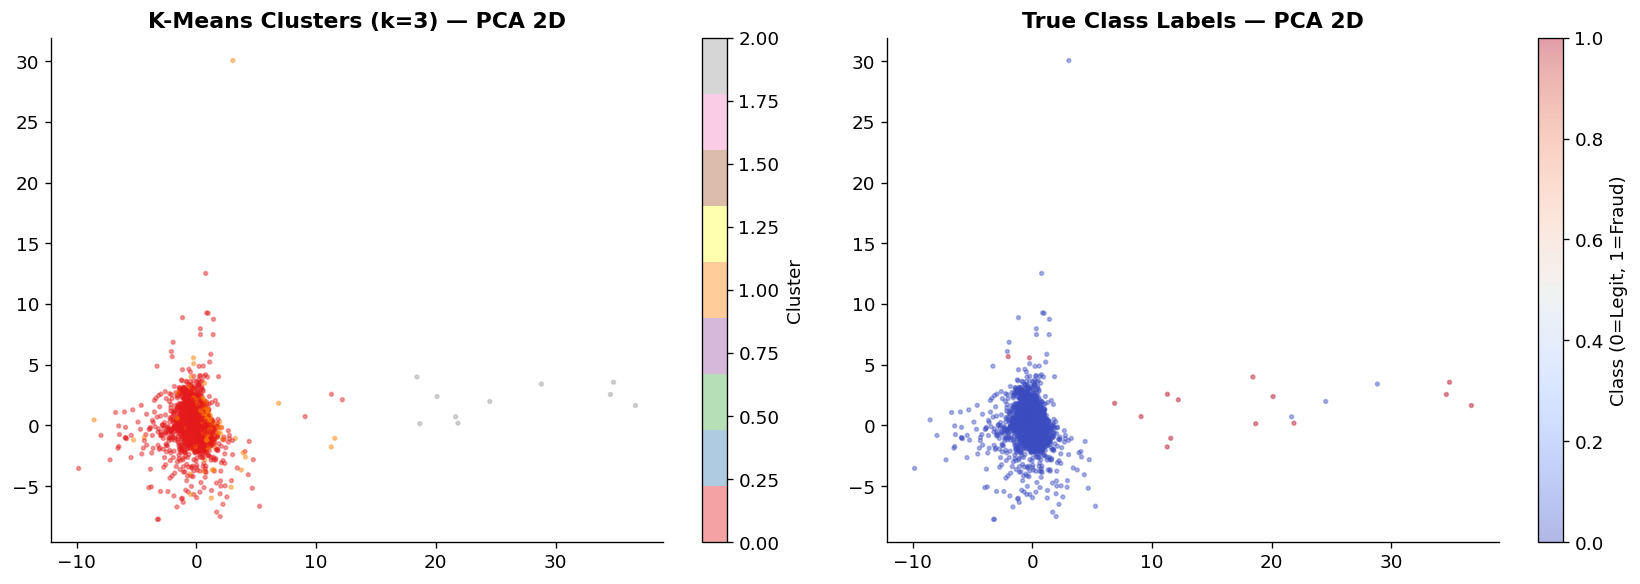

In [35]:
# 7.1(b)–(c) Cluster analysis
km_best = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
km_labels = km_best.fit_predict(X_clust)
df_sample['KMeans_Cluster'] = km_labels

print('7.1(b) Cluster vs. True Class Crosstab:')
crosstab = pd.crosstab(km_labels, y_clust, rownames=['Cluster'], colnames=['True Class'])
print(crosstab)

print('\n7.1(c) Per-Cluster Statistics:')
cluster_stats = df_sample.groupby('KMeans_Cluster').agg(
    mean_Amount=('Amount','mean'),
    mean_Time  =('Time','mean'),
    n_samples  =('Class','count'),
    fraud_rate =('Class','mean')
).round(4)
cluster_stats['fraud_pct'] = (cluster_stats['fraud_rate'] * 100).round(2)
print(cluster_stats.to_string())

# Visualise clusters with PCA 2D projection
from sklearn.decomposition import PCA
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_clust)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=km_labels, cmap='Set1',
                           s=5, alpha=0.4)
axes[0].set_title(f'K-Means Clusters (k={optimal_k}) — PCA 2D', fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(X_pca[:,0], X_pca[:,1], c=y_clust, cmap='coolwarm',
                            s=5, alpha=0.4)
axes[1].set_title('True Class Labels — PCA 2D', fontweight='bold')
plt.colorbar(scatter2, ax=axes[1], label='Class (0=Legit, 1=Fraud)')

plt.tight_layout(); plt.savefig('fig_7_1_kmeans.png', dpi=150); plt.show()

## Task 7.2: Hierarchical Clustering

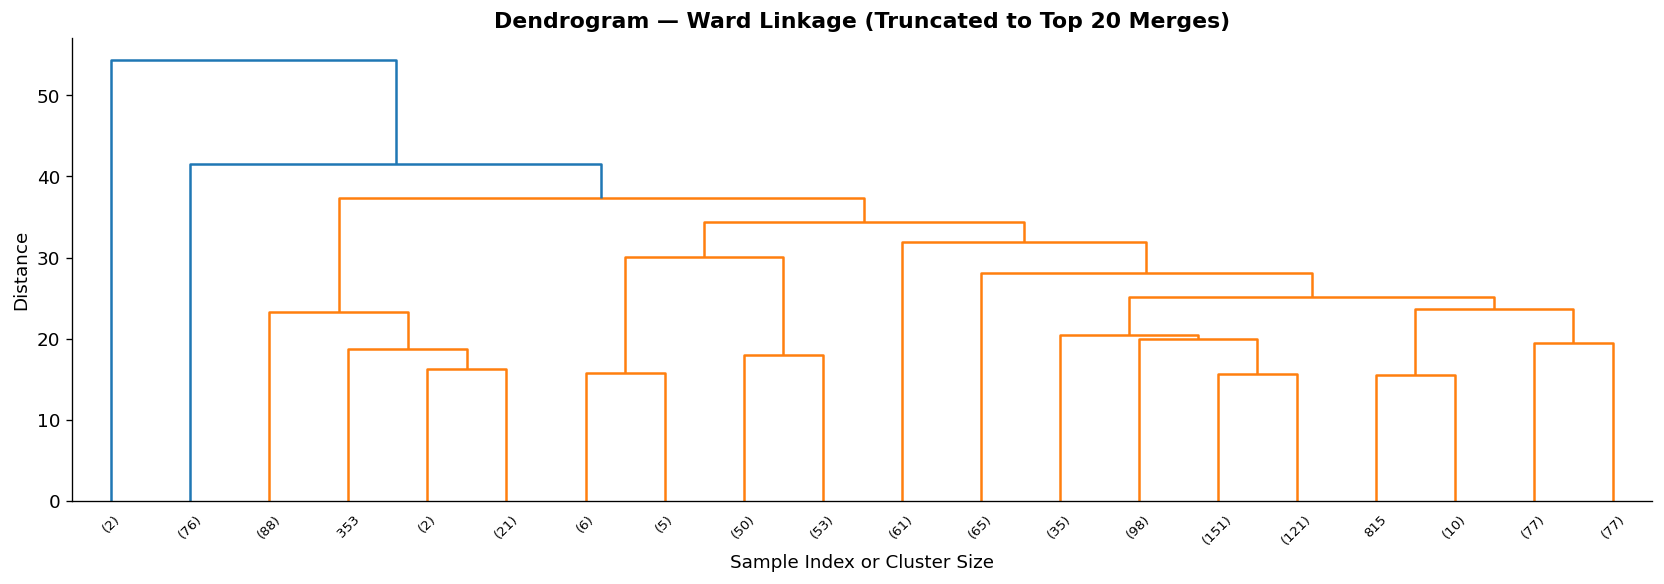


Dendrogram Interpretation:
The dendrogram shows a clear gap (long vertical lines) at 2–3 merges from the top,
suggesting 2–3 natural clusters. We choose k=2 (matching the binary fraud/legit
structure) or k=3 based on the visible elbow in the merge heights.



In [36]:
# 7.2(a) Agglomerative — Dendrogram (Ward linkage)

# Use a subset of 1000 for dendrogram readability
# -----------------------------------------------------------------------

X_dendro = X_clust[:1000]

Z = linkage(X_dendro, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=8, ax=ax)
ax.set_title('Dendrogram — Ward Linkage (Truncated to Top 20 Merges)', fontweight='bold')
ax.set_xlabel('Sample Index or Cluster Size')
ax.set_ylabel('Distance')
plt.tight_layout(); plt.savefig('fig_7_2_dendrogram.png', dpi=150); plt.show()

print("""
Dendrogram Interpretation:
The dendrogram shows a clear gap (long vertical lines) at 2–3 merges from the top,
suggesting 2–3 natural clusters. We choose k=2 (matching the binary fraud/legit
structure) or k=3 based on the visible elbow in the merge heights.
""")

HIER_K = optimal_k  # use same optimal k as KMeans

In [37]:
# 7.2(b) Ward, Complete, Average linkage comparison
# -----------------------------------------------------------------------

linkage_methods = ['ward', 'complete', 'average']
hier_results = {}

for method in linkage_methods:
    agg = AgglomerativeClustering(n_clusters=HIER_K, linkage=method)
    labels_h = agg.fit_predict(X_clust)
    sil = silhouette_score(X_clust, labels_h, sample_size=3000, random_state=42)
    fraud_rates = []
    for c in range(HIER_K):
        mask = labels_h == c
        fraud_rates.append(y_clust[mask].mean())
    hier_results[method] = {'labels': labels_h, 'silhouette': sil, 'fraud_rates': fraud_rates}
    print(f'{method:8s}: Silhouette={sil:.4f}, Fraud rates per cluster={[round(r,4) for r in fraud_rates]}')

best_linkage = max(hier_results, key=lambda m: hier_results[m]['silhouette'])
print(f'\nBest linkage method: {best_linkage}')

ward    : Silhouette=0.1432, Fraud rates per cluster=[0.0005, 0.8125, 0.0]
complete: Silhouette=0.8896, Fraud rates per cluster=[0.0014, 0.0, 0.5]
average : Silhouette=0.8713, Fraud rates per cluster=[0.001, 0.0, 0.7]

Best linkage method: complete


In [38]:
# 7.2(c) Divisive (Top-Down) Clustering via Bisecting K-Means
# -----------------------------------------------------------------------

def bisecting_kmeans(X, n_clusters, random_state=42):
    """
    Recursive bisecting K-Means.
    Splits the largest cluster at each step using K-Means with k=2.
    """
    # Start with one cluster containing all data
    labels = np.zeros(len(X), dtype=int)
    current_k = 1

    while current_k < n_clusters:
        # Find the largest cluster
        cluster_sizes = [(np.sum(labels == c), c) for c in range(current_k)]
        _, largest_c = max(cluster_sizes)

        mask = labels == largest_c
        X_sub = X[mask]

        km2 = KMeans(n_clusters=2, random_state=random_state, n_init=5)
        sub_labels = km2.fit_predict(X_sub)

        # Relabel: keep cluster `largest_c` for sub_labels==0,
        #          assign new cluster id for sub_labels==1
        new_labels = labels.copy()
        indices = np.where(mask)[0]
        new_labels[indices[sub_labels == 1]] = current_k
        labels = new_labels
        current_k += 1

    return labels

div_labels = bisecting_kmeans(X_clust, n_clusters=HIER_K)
sil_div = silhouette_score(X_clust, div_labels, sample_size=3000, random_state=42)
print(f'Divisive (Bisecting K-Means) Silhouette Score: {sil_div:.4f}')
print('Cluster distribution:', dict(zip(*np.unique(div_labels, return_counts=True))))

fraud_rates_div = [y_clust[div_labels==c].mean() for c in range(HIER_K)]
print('Fraud rate per cluster:', [round(r, 4) for r in fraud_rates_div])

Divisive (Bisecting K-Means) Silhouette Score: 0.0977
Cluster distribution: {0: 4850, 1: 5144, 2: 6}
Fraud rate per cluster: [0.0014, 0.0008, 1.0]


In [41]:
# 7.2(d) Compare K-Means, Agglomerative (best), Divisive
# -----------------------------------------------------------------------

sil_km  = silhouette_score(X_clust, km_labels, sample_size=3000, random_state=42)
sil_agg = hier_results[best_linkage]['silhouette']

summary_clust = pd.DataFrame({
    'Method'          : ['K-Means', f'Agglomerative ({best_linkage})', 'Divisive (Bisecting)'],
    'Silhouette Score': [round(sil_km, 4), round(sil_agg, 4), round(sil_div, 4)],
    'Fraud Rate Cluster 0': [
        round(y_clust[km_labels==0].mean(), 4),
        round(hier_results[best_linkage]['fraud_rates'][0], 4),
        round(fraud_rates_div[0], 4)
    ],
})
print('=== Clustering Comparison ===')
print(summary_clust.to_string(index=False))

=== Clustering Comparison ===
                  Method  Silhouette Score  Fraud Rate Cluster 0
                 K-Means            0.2600                0.0006
Agglomerative (complete)            0.8896                0.0014
    Divisive (Bisecting)            0.0977                0.0014
